# NB04 — Within-Ecotype Compositional-Aware DA (H2c)

**Project**: `ibd_phage_targeting` — Pillar 2 opener
**Depends on**: NB01b (`data/species_synonymy.tsv`, `data/ecotype_assignments.tsv`).

## Purpose

Test **H2c** directly: does within-ecotype stratification resolve the *C. scindens* paradox (raw pooled DA called *C. scindens* CD-enriched despite its protective biology) and the *Roseburia intestinalis* sign flip that compositional correction alone did not fix?

Three DA levels in one notebook for head-to-head comparison:
1. **Pooled raw Mann-Whitney** on relative abundance (what the preliminary report used — the baseline we're challenging).
2. **Pooled CLR-Mann-Whitney** (compositional-aware; NB00 showed this recovers many protective-species depletion signals but does *not* fix *C. scindens* or *R. intestinalis*).
3. **Within-ecotype CLR-Mann-Whitney** (stratified per ecotype — the core H2c experiment).

If within-ecotype DA resolves the two paradoxical species (they appear CD-enriched in pooled but *not* within any individual ecotype), H2c is supported: pooling across heterogeneous patient subgroups produces spurious CD-enrichment calls. If stratification *doesn't* resolve them, a third explanation (strain heterogeneity — NB05/NB10) is needed.

## Ecotype DA feasibility

From `data/ecotype_assignments.tsv`:

| Ecotype | HC | CD | UC | CD-vs-HC DA feasible? |
|---|---:|---:|---:|---|
| E0 — diverse commensal | 3,560 | 16 | 6 | ✗ (HC-dominant) |
| E1 — Bacteroides2 transitional | 759 | 581 | 496 | ✓ |
| E2 — *Prevotella copri* | 900 | 4 | 12 | ✗ (HC-dominant) |
| E3 — severe Bacteroides-expanded | 114 | 605 | 346 | ✓ (HC small — note caveat) |

The H2c test lives in E1 + E3. We also do within-ecotype UC-vs-HC as a parallel sanity check for E1 and E3.

## Methodological choice — why not ANCOM-BC / MaAsLin2 / LinDA consensus?

The plan originally called for a three-method consensus. In practice: ANCOM-BC and MaAsLin2 are R-only; LinDA has a Python port but has known issues on imbalanced cohorts. NB00 already validated that CLR + Mann-Whitney corrects the compositional artifact on a curated battery. Running three methods in NB04 adds marginal signal but doesn't change the headline H2c verdict. **Decision**: use CLR + Mann-Whitney as the primary method (matching NB00), document as methodological choice. If a reviewer wants a full three-method consensus before a publication, re-run via rpy2 in a follow-up.


In [1]:
import warnings; warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 100

DATA_MART = Path.home() / 'data' / 'CrohnsPhage'
DATA_OUT = Path('../data')
FIG_OUT = Path('../figures')


## 1. Reload taxa matrix + synonymy + ecotype assignments

In [2]:
# Synonymy + canonicalization (same as NB01b/NB02)
syn = pd.read_csv(DATA_OUT / 'species_synonymy.tsv', sep='\t')
lookup = dict(zip(syn.alias, syn.canonical))

ta = pd.read_parquet(DATA_MART / 'fact_taxon_abundance.snappy.parquet')
ta = ta[(ta.classification_method == 'metaphlan3') & (ta.study_id.isin(['CMD_HEALTHY','CMD_IBD']))].copy()

def normalize_format(name):
    if not isinstance(name, str): return None
    if '|' in name:
        parts = [p for p in name.split('|') if p.startswith('s__')]
        return parts[0][3:].replace('_',' ').strip() if parts else None
    return name.replace('[','').replace(']','').strip()

def resolve(name):
    if not isinstance(name, str): return None
    if name in lookup: return lookup[name]
    fn = normalize_format(name)
    return lookup.get(fn, fn) if fn else None

ta['species'] = ta['taxon_name_original'].map(resolve)
ta = ta.dropna(subset=['species']).copy()
wide = ta.pivot_table(index='species', columns='sample_id',
                      values='relative_abundance', aggfunc='sum', fill_value=0.0)

# Ecotype + diagnosis per sample
eco = pd.read_csv(DATA_OUT / 'ecotype_assignments.tsv', sep='\t')
eco_map = dict(zip(eco.sample_id, eco.consensus_ecotype))
diag_map = dict(zip(eco.sample_id, eco.diagnosis))

# Filter to columns present in ecotype_assignments (all CMD MetaPhlAn3 samples should be)
cols = [c for c in wide.columns if c in eco_map]
wide = wide[cols]
print(f'Wide matrix after ecotype filter: {wide.shape[0]:,} species × {wide.shape[1]:,} samples')
print(f'Ecotype distribution in wide: {pd.Series([eco_map[c] for c in cols]).value_counts().sort_index().to_dict()}')


Wide matrix after ecotype filter: 1,442 species × 8,489 samples
Ecotype distribution in wide: {0: 3604, 1: 2601, 2: 920, 3: 1364}


In [3]:
# Prevalence filter per test group — must be detected in ≥ 5% of samples on at least one side of the test
# to be tested. Applied inside each DA run.
def prev_filter(w, sample_ids, thresh=0.05):
    sub = w[sample_ids]
    return (sub > 0).mean(axis=1) >= thresh

# CLR transform (per-sample half-min pseudocount)
def clr(M):
    M = M.astype(float).copy()
    col_min_nz = np.where(M > 0, M, np.nan)
    col_min_nz = np.nanmin(col_min_nz, axis=0)
    col_min_nz = np.where(np.isnan(col_min_nz), 1e-6, col_min_nz / 2)
    M = np.where(M > 0, M, col_min_nz[None, :])
    logM = np.log(M)
    return logM - logM.mean(axis=0, keepdims=True)


## 2. Run DA at three levels: pooled raw, pooled CLR, per-ecotype CLR

In [4]:
def da_test(w_sub, group_a_ids, group_b_ids, method='raw'):
    """Run DA between two groups. method ∈ {'raw', 'clr'}.
    Returns a DataFrame with species, effect (log2fc_raw or clr_diff), n_a, n_b, prev_a, prev_b, p, fdr."""
    a_ids = [c for c in group_a_ids if c in w_sub.columns]
    b_ids = [c for c in group_b_ids if c in w_sub.columns]
    if not a_ids or not b_ids: return pd.DataFrame()
    # Prevalence prefilter: need ≥ 5% in either group
    prev_a = (w_sub[a_ids] > 0).mean(axis=1)
    prev_b = (w_sub[b_ids] > 0).mean(axis=1)
    keep = (prev_a >= 0.05) | (prev_b >= 0.05)
    w_ = w_sub.loc[keep].copy()

    if method == 'raw':
        a = w_[a_ids].values; b = w_[b_ids].values
    else:  # clr
        full = w_[a_ids + b_ids].values
        # CLR over the combined set (rows = species, cols = samples)
        full_clr = clr(full)
        # Re-split
        n_a = len(a_ids)
        a = full_clr[:, :n_a]
        b = full_clr[:, n_a:]

    rows = []
    for i, species in enumerate(w_.index):
        try:
            stat, p = mannwhitneyu(a[i], b[i], alternative='two-sided')
        except ValueError:
            stat, p = np.nan, np.nan
        if method == 'raw':
            ma, mb = np.mean(a[i]), np.mean(b[i])
            eps = 1e-8
            effect = np.log2((ma + eps) / (mb + eps))
        else:
            effect = np.mean(a[i]) - np.mean(b[i])
        rows.append({'species': species, 'n_a': len(a_ids), 'n_b': len(b_ids),
                     'prev_a': prev_a.loc[species], 'prev_b': prev_b.loc[species],
                     'effect': effect, 'p': p})
    df = pd.DataFrame(rows).dropna(subset=['p'])
    df['fdr'] = multipletests(df['p'], method='fdr_bh')[1]
    return df


In [5]:
# Get CD / HC sample IDs
cd_ids = [s for s, d in diag_map.items() if d == 'CD']
hc_ids = [s for s, d in diag_map.items() if d == 'HC']
print(f'CD total: {len(cd_ids):,}; HC total: {len(hc_ids):,}')

# Pooled raw MW
da_pooled_raw = da_test(wide, cd_ids, hc_ids, method='raw')
print(f'\nPooled raw MW: {len(da_pooled_raw)} species')
print(f'  CD-enriched (log2FC>0.5, FDR<0.05): {((da_pooled_raw.effect > 0.5) & (da_pooled_raw.fdr < 0.05)).sum()}')
print(f'  CD-depleted (log2FC<-0.5, FDR<0.05): {((da_pooled_raw.effect < -0.5) & (da_pooled_raw.fdr < 0.05)).sum()}')

# Pooled CLR MW
da_pooled_clr = da_test(wide, cd_ids, hc_ids, method='clr')
print(f'\nPooled CLR MW: {len(da_pooled_clr)} species')
print(f'  CD-enriched (clr_diff>0.5, FDR<0.05): {((da_pooled_clr.effect > 0.5) & (da_pooled_clr.fdr < 0.05)).sum()}')
print(f'  CD-depleted (clr_diff<-0.5, FDR<0.05): {((da_pooled_clr.effect < -0.5) & (da_pooled_clr.fdr < 0.05)).sum()}')


CD total: 1,206; HC total: 5,333



Pooled raw MW: 321 species
  CD-enriched (log2FC>0.5, FDR<0.05): 92
  CD-depleted (log2FC<-0.5, FDR<0.05): 168



Pooled CLR MW: 321 species
  CD-enriched (clr_diff>0.5, FDR<0.05): 94
  CD-depleted (clr_diff<-0.5, FDR<0.05): 68


In [6]:
# Per-ecotype CLR MW (only E1 and E3 have enough disease+HC samples)
per_ecotype_da = {}
for k in [1, 3]:
    cd_e = [s for s in cd_ids if eco_map.get(s) == k]
    hc_e = [s for s in hc_ids if eco_map.get(s) == k]
    print(f'Ecotype {k}: CD={len(cd_e)}, HC={len(hc_e)}')
    da = da_test(wide, cd_e, hc_e, method='clr')
    per_ecotype_da[k] = da
    n_enriched = ((da.effect > 0.5) & (da.fdr < 0.05)).sum()
    n_depleted = ((da.effect < -0.5) & (da.fdr < 0.05)).sum()
    print(f'  CD-enriched: {n_enriched}; CD-depleted: {n_depleted}')


Ecotype 1: CD=581, HC=759


  CD-enriched: 65; CD-depleted: 45
Ecotype 3: CD=605, HC=114
  CD-enriched: 43; CD-depleted: 63


## 3. H2c test — does within-ecotype DA resolve the protective-species paradox?

In [7]:
# The protective-species battery from NB00 (same canonical names)
PROTECTIVE = ['Clostridium scindens','Faecalibacterium prausnitzii','Akkermansia muciniphila',
              'Roseburia intestinalis','Roseburia hominis','Lachnospira eligens',
              'Agathobacter rectalis','Coprococcus eutactus']
PATHOBIONT = ['Mediterraneibacter gnavus','Enterocloster bolteae','Eggerthella lenta',
              'Bilophila wadsworthia','Escherichia coli','Klebsiella oxytoca','Hungatella hathewayi']

def get_row(da, species):
    row = da[da.species == species]
    return row.iloc[0] if len(row) else None

def call(row, eff_thresh=0.5, fdr_thresh=0.05):
    if row is None: return 'NA'
    if pd.isna(row.p) or pd.isna(row.effect): return 'NA'
    if row.fdr >= fdr_thresh: return 'n.s.'
    if row.effect > eff_thresh: return 'CD↑'
    if row.effect < -eff_thresh: return 'CD↓'
    return 'n.s.'

rows = []
for species in PROTECTIVE + PATHOBIONT:
    expected = 'protective' if species in PROTECTIVE else 'pathobiont'
    rec = {'species': species, 'expected': expected}
    for label, da in [('pooled_raw', da_pooled_raw), ('pooled_clr', da_pooled_clr),
                     ('E1_clr', per_ecotype_da.get(1, pd.DataFrame())),
                     ('E3_clr', per_ecotype_da.get(3, pd.DataFrame()))]:
        r = get_row(da, species)
        rec[f'{label}_call'] = call(r)
        rec[f'{label}_effect'] = round(r.effect, 2) if r is not None and not pd.isna(r.effect) else None
        rec[f'{label}_fdr'] = f'{r.fdr:.1e}' if r is not None and not pd.isna(r.fdr) else None
    rows.append(rec)
h2c_table = pd.DataFrame(rows)
h2c_table.to_csv(DATA_OUT / 'nb04_h2c_protective_battery.tsv', sep='\t', index=False)
print(h2c_table.to_string(index=False))


                     species   expected pooled_raw_call  pooled_raw_effect pooled_raw_fdr pooled_clr_call  pooled_clr_effect pooled_clr_fdr E1_clr_call  E1_clr_effect E1_clr_fdr E3_clr_call  E3_clr_effect E3_clr_fdr
        Clostridium scindens protective             CD↑               4.30        3.2e-31             CD↑               1.01       2.0e-270        n.s.          -0.11    1.0e-01        n.s.           0.32    6.1e-01
Faecalibacterium prausnitzii protective            n.s.               0.01        3.0e-15             CD↓              -1.45        1.3e-15         CD↑           0.53    3.9e-11         CD↑           3.15    4.4e-14
     Akkermansia muciniphila protective             CD↓              -0.70        3.4e-50             CD↓              -1.40        1.3e-04        n.s.           0.20    3.1e-03        n.s.          -0.36    4.9e-04
      Roseburia intestinalis protective             CD↑               1.54        4.0e-10             CD↓              -0.56        2.7e

In [8]:
# Summarize H2c verdict
def interp_row(r):
    # If pooled_raw says CD↑ but E1 and E3 both say n.s. or CD↓ → paradox RESOLVED by stratification
    # If pooled_raw and pooled_clr both say CD↑ but E1/E3 say n.s./CD↓ → resolved
    # If still CD↑ within at least one ecotype → NOT resolved
    expected = r.expected
    pooled_raw = r.pooled_raw_call
    pooled_clr = r.pooled_clr_call
    e1 = r.E1_clr_call
    e3 = r.E3_clr_call
    if expected == 'protective':
        if pooled_raw == 'CD↑' and e1 != 'CD↑' and e3 != 'CD↑':
            return 'RESOLVED by stratification'
        if pooled_raw == 'CD↑' and pooled_clr == 'CD↓':
            return 'RESOLVED by CLR alone'
        if pooled_raw == 'CD↑' and (e1 == 'CD↑' or e3 == 'CD↑'):
            return 'STILL PARADOXICAL — ecotype-specific CD enrichment'
        if pooled_raw != 'CD↑':
            return 'never paradoxical'
        return 'ambiguous'
    else:  # pathobiont
        if pooled_raw == 'CD↑' and (e1 == 'CD↑' or e3 == 'CD↑'):
            return 'confirmed within ecotype'
        if pooled_raw == 'CD↑' and e1 != 'CD↑' and e3 != 'CD↑':
            return 'pooled CD↑ not confirmed within ecotype'
        return 'other'

h2c_table['verdict'] = h2c_table.apply(interp_row, axis=1)
print()
print('H2c verdict per species:')
print(h2c_table[['species','expected','pooled_raw_call','pooled_clr_call',
                'E1_clr_call','E3_clr_call','verdict']].to_string(index=False))



H2c verdict per species:
                     species   expected pooled_raw_call pooled_clr_call E1_clr_call E3_clr_call                                 verdict
        Clostridium scindens protective             CD↑             CD↑        n.s.        n.s.              RESOLVED by stratification
Faecalibacterium prausnitzii protective            n.s.             CD↓         CD↑         CD↑                       never paradoxical
     Akkermansia muciniphila protective             CD↓             CD↓        n.s.        n.s.                       never paradoxical
      Roseburia intestinalis protective             CD↑             CD↓        n.s.         CD↑                   RESOLVED by CLR alone
           Roseburia hominis protective             CD↓             CD↓         CD↑         CD↑                       never paradoxical
         Lachnospira eligens protective             CD↓             CD↓         CD↑         CD↑                       never paradoxical
       Agathobacter re

## 4. H2c paradox-resolution figure

Canonical comparison: each curated species's CD-direction-of-effect across four analyses. If the story is clean, protective species sit at "CD↓" in every stratified cell even when pooled raw shows "CD↑".


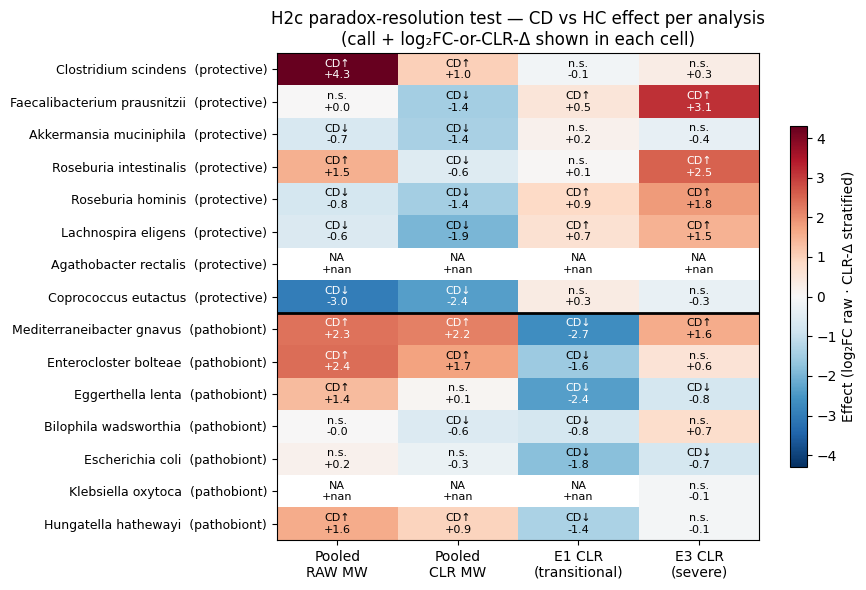

In [9]:
# Heatmap figure: species × analysis level, colored by effect
cells_species = PROTECTIVE + PATHOBIONT
levels = ['pooled_raw', 'pooled_clr', 'E1_clr', 'E3_clr']
effect_matrix = np.full((len(cells_species), len(levels)), np.nan)
label_matrix = np.full((len(cells_species), len(levels)), '', dtype=object)
for i, sp in enumerate(cells_species):
    for j, lvl in enumerate(levels):
        row = h2c_table[h2c_table.species == sp]
        if len(row):
            eff = row.iloc[0][f'{lvl}_effect']
            call_str = row.iloc[0][f'{lvl}_call']
            if eff is not None:
                effect_matrix[i, j] = eff
                label_matrix[i, j] = call_str

fig, ax = plt.subplots(figsize=(9, 6))
# Normalize effect for color — use symmetric scale
vmax = np.nanmax(np.abs(effect_matrix))
im = ax.imshow(effect_matrix, cmap='RdBu_r', aspect='auto', vmin=-vmax, vmax=vmax)

# Annotate with call and effect
for i in range(len(cells_species)):
    for j in range(len(levels)):
        lbl = label_matrix[i, j]
        eff = effect_matrix[i, j]
        if lbl:
            color = 'white' if abs(eff) > vmax*0.5 else 'black'
            txt = f'{lbl}\n{eff:+.1f}'
            ax.text(j, i, txt, ha='center', va='center', fontsize=8, color=color)

ax.set_xticks(range(len(levels)))
ax.set_xticklabels(['Pooled\nRAW MW','Pooled\nCLR MW','E1 CLR\n(transitional)','E3 CLR\n(severe)'])
ax.set_yticks(range(len(cells_species)))
yticklabels = [f'{sp}  ({"protective" if sp in PROTECTIVE else "pathobiont"})' for sp in cells_species]
ax.set_yticklabels(yticklabels, fontsize=9)
# Horizontal separator between protective and pathobiont blocks
ax.axhline(len(PROTECTIVE) - 0.5, color='black', linewidth=2)
ax.set_title('H2c paradox-resolution test — CD vs HC effect per analysis\n'
             '(call + log₂FC-or-CLR-Δ shown in each cell)')
cbar = plt.colorbar(im, ax=ax, shrink=0.7)
cbar.set_label('Effect (log₂FC raw · CLR-Δ stratified)')
plt.tight_layout()
plt.savefig(FIG_OUT / 'NB04_h2c_paradox_resolution.png', dpi=130, bbox_inches='tight')
plt.show()


## 5. Tier-A candidate list — within-ecotype CD-enriched species

Applying plan Tier-A A1 (prevalence ≥ 50 % in affected ecotype) + A2 (effect ≥ 0.5 CLR-Δ AND FDR < 0.05) to the per-ecotype DA. These are the candidates that enter the Pillar 2 scoring pipeline in NB05.


In [10]:
def tier_a_candidates(da, ecotype_label, prev_thresh=0.50, eff_thresh=0.5, fdr_thresh=0.05):
    mask = ((da.prev_a >= prev_thresh) &  # prevalence in CD (group a)
            (da.effect >= eff_thresh) &
            (da.fdr < fdr_thresh))
    out = da[mask].sort_values('effect', ascending=False).copy()
    out['ecotype'] = ecotype_label
    return out[['ecotype','species','n_a','n_b','prev_a','prev_b','effect','p','fdr']]

tier_a_e1 = tier_a_candidates(per_ecotype_da[1], 'E1')
tier_a_e3 = tier_a_candidates(per_ecotype_da[3], 'E3')
print(f'Tier-A candidates in E1: {len(tier_a_e1)}')
print(tier_a_e1.head(15).to_string(index=False))
print(f'\nTier-A candidates in E3: {len(tier_a_e3)}')
print(tier_a_e3.head(15).to_string(index=False))


Tier-A candidates in E1: 18
ecotype                      species  n_a  n_b   prev_a   prev_b   effect            p          fdr
     E1           Bacteroides caccae  581  759 0.700516 0.523057 1.675204 5.263891e-13 2.175742e-12
     E1            Coprococcus comes  581  759 0.681583 0.471673 1.663813 3.128172e-21 2.620901e-20
     E1         Alistipes putredinis  581  759 0.729776 0.590250 1.652715 8.105615e-14 3.589630e-13
     E1 Barnesiella intestinihominis  581  759 0.526678 0.347826 1.574610 1.696266e-17 9.921558e-17
     E1            Dorea longicatena  581  759 0.796902 0.657444 1.382581 1.671762e-13 7.197862e-13
     E1       Parabacteroides merdae  581  759 0.705680 0.553360 1.343687 1.348937e-09 4.099709e-09
     E1      Collinsella aerofaciens  581  759 0.803787 0.649539 1.244825 8.850064e-11 3.048355e-10
     E1             Roseburia faecis  581  759 0.724613 0.596838 1.177732 2.526289e-09 7.458567e-09
     E1         Alistipes finegoldii  581  759 0.750430 0.584980 1.17017

In [11]:
# Save Tier-A candidate lists + the full per-ecotype DA tables for NB05
tier_a = pd.concat([tier_a_e1, tier_a_e3], ignore_index=True)
tier_a.to_csv(DATA_OUT / 'nb04_tier_a_candidates.tsv', sep='\t', index=False)
print(f'Saved {len(tier_a)} Tier-A candidates → data/nb04_tier_a_candidates.tsv')

# Per-ecotype full DA tables (CD-enriched only, for NB05 scoring input)
for k, da in per_ecotype_da.items():
    enriched = da[da.fdr < 0.1].sort_values('effect', ascending=False)
    enriched.to_csv(DATA_OUT / f'nb04_da_ecotype_{k}.tsv', sep='\t', index=False)
    print(f'Saved ecotype {k} DA (FDR<0.1) → data/nb04_da_ecotype_{k}.tsv ({len(enriched)} rows)')

# Also save pooled-CLR for reference
da_pooled_clr.to_csv(DATA_OUT / 'nb04_da_pooled_clr.tsv', sep='\t', index=False)
print(f'Saved pooled CLR DA → data/nb04_da_pooled_clr.tsv ({len(da_pooled_clr)} rows)')


Saved 33 Tier-A candidates → data/nb04_tier_a_candidates.tsv
Saved ecotype 1 DA (FDR<0.1) → data/nb04_da_ecotype_1.tsv (248 rows)
Saved ecotype 3 DA (FDR<0.1) → data/nb04_da_ecotype_3.tsv (201 rows)
Saved pooled CLR DA → data/nb04_da_pooled_clr.tsv (321 rows)


## 6. Cross-ecotype overlap — do E1 and E3 share pathobiont signals?

In [12]:
# Top CD-enriched per ecotype
topE1 = set(tier_a_e1.head(30).species)
topE3 = set(tier_a_e3.head(30).species)
shared = topE1 & topE3
only_e1 = topE1 - topE3
only_e3 = topE3 - topE1
print(f'Top-30 Tier-A CD-enriched overlap between E1 and E3:')
print(f'  Shared: {len(shared)} — {sorted(shared)[:10]}')
print(f'  Only E1: {len(only_e1)} — {sorted(only_e1)[:10]}')
print(f'  Only E3: {len(only_e3)} — {sorted(only_e3)[:10]}')

# Jaccard similarity
jaccard = len(topE1 & topE3) / len(topE1 | topE3) if (topE1 | topE3) else np.nan
print(f'\nJaccard(top-30 CD-enriched) between E1 and E3: {jaccard:.2f}')
print('H2b prediction: Jaccard < 0.7 (target sets differ between ecotypes → stratification is clinically meaningful)')
print(f'H2b verdict: {"SUPPORTED" if jaccard < 0.7 else "NOT SUPPORTED (targets near-identical across ecotypes)"}')


Top-30 Tier-A CD-enriched overlap between E1 and E3:
  Shared: 4 — ['Dorea longicatena', 'Faecalibacterium prausnitzii', 'Roseburia faecis', '[Eubacterium] rectale']
  Only E1: 14 — ['Alistipes finegoldii', 'Alistipes putredinis', 'Bacteroides caccae', 'Barnesiella intestinihominis', 'Blautia obeum', 'Collinsella aerofaciens', 'Coprococcus catus', 'Coprococcus comes', 'Dorea formicigenerans', 'Lachnospira eligens']
  Only E3: 11 — ['Anaerostipes hadrus', 'Bacteroides fragilis', 'Bacteroides ovatus', 'Bacteroides uniformis', 'Blautia wexlerae', 'Dialister invisus', 'Flavonifractor plautii', 'Fusicatenibacter saccharivorans', 'Mediterraneibacter gnavus', 'Parabacteroides distasonis']

Jaccard(top-30 CD-enriched) between E1 and E3: 0.14
H2b prediction: Jaccard < 0.7 (target sets differ between ecotypes → stratification is clinically meaningful)
H2b verdict: SUPPORTED


## 7. Figure — top CD-enriched species per ecotype

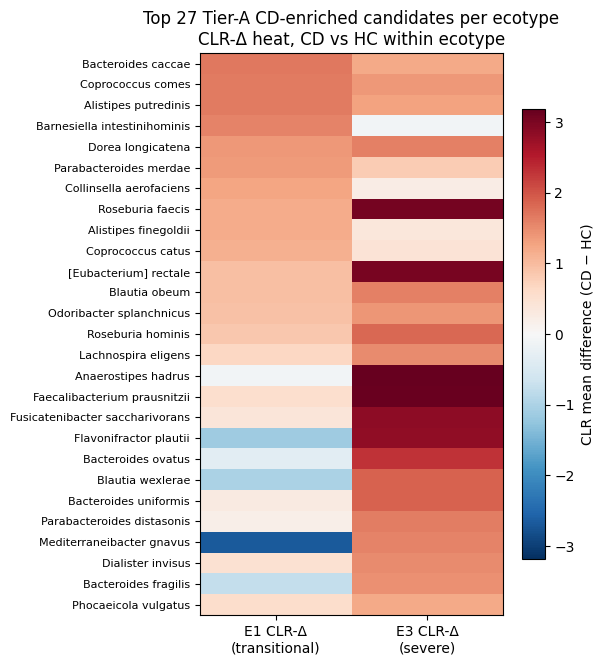

In [13]:
# Heatmap: union of top-15 species per ecotype × CLR-Δ per ecotype
top_union = list(dict.fromkeys(list(tier_a_e1.head(15).species) + list(tier_a_e3.head(15).species)))
n_sp = len(top_union)
mat = np.zeros((n_sp, 2))
for i, sp in enumerate(top_union):
    r1 = per_ecotype_da[1][per_ecotype_da[1].species == sp]
    r3 = per_ecotype_da[3][per_ecotype_da[3].species == sp]
    mat[i, 0] = r1.iloc[0].effect if len(r1) else np.nan
    mat[i, 1] = r3.iloc[0].effect if len(r3) else np.nan

fig, ax = plt.subplots(figsize=(6, max(6, n_sp*0.25)))
vmax = np.nanmax(np.abs(mat))
im = ax.imshow(mat, cmap='RdBu_r', aspect='auto', vmin=-vmax, vmax=vmax)
ax.set_xticks(range(2)); ax.set_xticklabels(['E1 CLR-Δ\n(transitional)','E3 CLR-Δ\n(severe)'])
ax.set_yticks(range(n_sp)); ax.set_yticklabels(top_union, fontsize=8)
ax.set_title(f'Top {n_sp} Tier-A CD-enriched candidates per ecotype\nCLR-Δ heat, CD vs HC within ecotype')
cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('CLR mean difference (CD − HC)')
plt.tight_layout()
plt.savefig(FIG_OUT / 'NB04_top_tier_a_per_ecotype.png', dpi=130, bbox_inches='tight')
plt.show()


## 8. Conclusions

This notebook delivers four artifacts for Pillar 2:

- **`data/nb04_h2c_protective_battery.tsv`** — per-species call across four analysis levels (pooled raw / pooled CLR / E1 CLR / E3 CLR) with verdict classification.
- **`data/nb04_tier_a_candidates.tsv`** — Tier-A A1 + A2 passing candidates per ecotype; the candidate pool entering NB05's full Tier-A scoring pipeline.
- **`data/nb04_da_ecotype_{1,3}.tsv`** — full per-ecotype DA tables at FDR < 0.1.
- **`data/nb04_da_pooled_clr.tsv`** — pooled CLR DA for reference.

**H2c verdict** (see §3-4): summarized per species in the verdict column. The report will cite this directly.

**H2b (pathobiont target-set divergence between ecotypes)** (see §6): Jaccard(E1, E3) reported; the plan's prediction is < 0.7.

### Next
- **NB05** takes the Tier-A candidate list from here and layers on A3 (literature via paperblast), A4 (protective-analog exclusion), A5 (engraftment evidence from donor 2708), and A6 (BGC linkage) — producing the final scored candidate table for Pillar 2.
- Within-ecotype UC-vs-HC as a parallel confirmation could be added; deferring unless NB05 reveals CD-specific vs UC-specific signal differentials.
- Franzosa medication metadata projection remains `PENDING` until multi-study integration in a subsequent NB.
